### Imports

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

sys.path.append("..")

from src.data.load_data import load_tables
from src.data.joins import build_dataset, join_summary
from src.features.temporal_features import add_temporal_features
from src.features.cyclic_features import add_cyclic_features
from src.features.historical_features import add_historical_features
from src.features.encoding import FrequencyEncoder, TargetEncoder

SEED       = 42
OUTPUT_DIR = Path().resolve().parent / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


### Load tables

In [2]:
accidents, weather, raw = load_tables()

### Binary Target Construction

In [3]:
df = build_dataset(accidents, weather)
join_summary(df)

Dataset built: (7991780, 16)
  Positive cases (target=1): 120,475 (1.51 %)
  Negative cases (target=0): 7,871,305

── Dataset Summary ──────────────────────────────
Total rows        : 7,991,780
Unique neighborhoods : 319
Time range        : 2017-01-01 00:00:00 → 2019-12-31 23:00:00
Total missing values : 3276350
Class imbalance   : {0: 0.9849, 1: 0.0151}


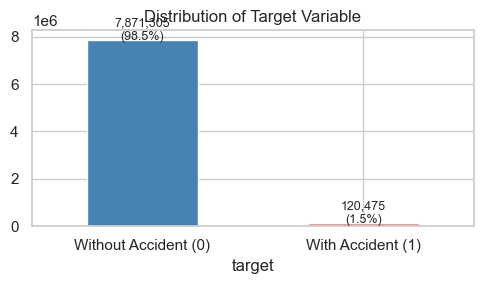


 Positive class: 1.51% — imbalanced problem.


In [4]:
count = df['target'].value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
count.plot(kind='bar', ax=ax, color=['steelblue','salmon'], edgecolor='white')
ax.set_xticklabels(['Without Accident (0)', 'With Accident (1)'], rotation=0)
ax.set_title('Distribution of Target Variable')
for i, v in enumerate(count):
    ax.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print(f'\n Positive class: {df["target"].mean()*100:.2f}% — imbalanced problem.')

### Temporal Variables

In [5]:
df = add_temporal_features(df)
print('Nuevas columnas:', ['hour','weekday_num','is_weekend','is_holiday','time_period'])
df[['TW','hour','weekday_num','is_weekend','is_holiday','time_period']].head(4)

Nuevas columnas: ['hour', 'weekday_num', 'is_weekend', 'is_holiday', 'time_period']


,TW,hour,weekday_num,is_weekend,is_holiday,time_period
0,2017-01-01 00:00:00,0,6,1,0,early_morning
1,2017-01-01 01:00:00,1,6,1,0,early_morning
2,2017-01-01 02:00:00,2,6,1,0,early_morning
3,2017-01-01 03:00:00,3,6,1,0,early_morning


### Cyclical variables

New features added: hour_sin/cos, weekday_sin/cos, dayOfYear_sin/cos, month_sin/cos


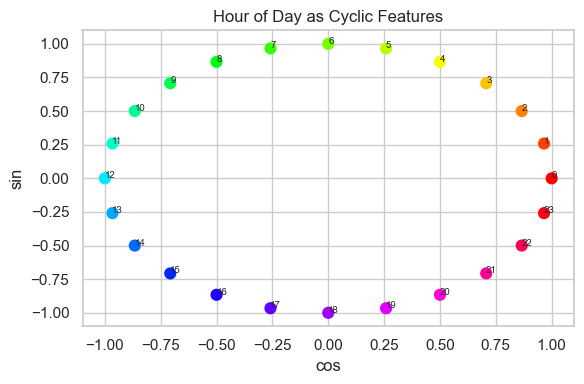

In [6]:
df = add_cyclic_features(df)
print('New features added: hour_sin/cos, weekday_sin/cos, dayOfYear_sin/cos, month_sin/cos')

hours = pd.DataFrame({'hour': range(24)})
hours['sin'] = np.sin(2*np.pi*hours['hour']/24)
hours['cos'] = np.cos(2*np.pi*hours['hour']/24)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(hours['cos'], hours['sin'], c=hours['hour'], cmap='hsv', s=60)
for _, r in hours.iterrows():
    ax.annotate(int(r['hour']), (r['cos'], r['sin']), fontsize=7)
ax.set_title('Hour of Day as Cyclic Features')
ax.set_xlabel('cos'); ax.set_ylabel('sin')
plt.tight_layout(); plt.show()

### Historycal Variables

In [7]:
df = add_historical_features(df, raw)
df[['TW','BARRIO','target',
    'hist_acc_neighborhood_total','hist_acc_neighborhood_30d',
    'hist_acc_hour_neighborhood','hist_rate_neighborhood']].head(6)

Historical features added: hist_acc_neighborhood_total, hist_acc_neighborhood_30d, hist_acc_hour_neighborhood, hist_rate_neighborhood


,TW,BARRIO,target,hist_acc_neighborhood_total,hist_acc_neighborhood_30d,hist_acc_hour_neighborhood,hist_rate_neighborhood
0,2017-01-01,AGUASFRIAS,0,0.0,0.0,1.0,1.000000
1,2017-01-01,UPB,0,0.0,0.0,0.0,1.010870
2,2017-01-01,CORREGIMIENTODESANANTONIODEPRADO,0,0.0,0.0,0.0,1.000000
3,2017-01-01,LALADERA,0,0.0,0.0,3.0,1.000000
4,2017-01-01,SIMONBOLIVAR,0,0.0,0.0,2.0,1.003891
5,2017-01-01,LALIBERTAD,0,0.0,0.0,2.0,1.004878


### Define Data Columns

In [17]:
DROP_COLS = ['TW', 'target']

COLS_TARGET_ENC = ['BARRIO']
COLS_FREQ_ENC   = ['summary', 'icon', 'time_period']

NUMERIC_COLS = [
    'Lat', 'Lon',
    'hour', 'weekday_num', 'is_weekend', 'is_holiday',
    'hour_sin', 'hour_cos',
    'weekday_sin', 'weekday_cos',
    'dayOfYear_sin', 'dayOfYear_cos',
    'month_sin', 'month_cos',
    'temperature', 'apparentTemperature', 'dewPoint', 'humidity',
    'precipIntensity', 'precipProbability',
    'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility',
    'hist_acc_neighborhood_total', 'hist_acc_neighborhood_30d',
    'hist_acc_hour_neighborhood', 'hist_rate_neighborhood',
]

NUMERIC_COLS    = [c for c in NUMERIC_COLS    if c in df.columns]
COLS_TARGET_ENC = [c for c in COLS_TARGET_ENC if c in df.columns]
COLS_FREQ_ENC   = [c for c in COLS_FREQ_ENC   if c in df.columns]

print(f'Numéricas:      {len(NUMERIC_COLS)}')
print(f'Columnas:       {NUMERIC_COLS}')
print(f'Target Enc:     {COLS_TARGET_ENC}')
print(f'Frequency Enc:  {COLS_FREQ_ENC}')

Numéricas:      25
Columnas:       ['hour', 'weekday_num', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'precipIntensity', 'precipProbability', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility', 'hist_acc_neighborhood_total', 'hist_acc_neighborhood_30d', 'hist_acc_hour_neighborhood', 'hist_rate_neighborhood']
Target Enc:     ['BARRIO']
Frequency Enc:  ['summary', 'icon', 'time_period']


### Split temporal train / test

El split se realiza ordenando el dataset por `TW` y reservando el 20 % final como test.
Esto garantiza que el conjunto de prueba contenga sólo datos posteriores a los usados en entrenamiento, evitando fuga temporal.
La selección de umbral y la validación interna se realizan en `05_validation_model_selection.ipynb`; aquí sólo se prepara el train/test temporal.


In [18]:
# Orden temporal por TW para garantizar un split train/test honesto
# El 80 % inicial es train y el 20 % final es test (sin shuffle).
df_sorted = df.sort_values('TW').reset_index(drop=True)

cut = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:cut].copy()
test  = df_sorted.iloc[cut:].copy()

feature_cols = NUMERIC_COLS + COLS_TARGET_ENC + COLS_FREQ_ENC
feature_cols = [c for c in feature_cols if c in df.columns]

X_train = train[feature_cols]
y_train = train['target']
X_test  = test[feature_cols]
y_test  = test['target']

print(f'Train: {X_train.shape}  ({train["TW"].min().date()} → {train["TW"].max().date()})')
print(f'Test : {X_test.shape}   ({test["TW"].min().date()} → {test["TW"].max().date()})')
print(f'\nTarget train: {y_train.mean()*100:.2f}% positives')
print(f'Target test : {y_test.mean()*100:.2f}% positives')

Train: (6393424, 29)  (2017-01-01 → 2019-05-22)
Test : (1598356, 29)   (2019-05-22 → 2019-12-31)

Target train: 1.47% positives
Target test : 1.66% positives


### Encoding - Fit in train, Transform in test

In [19]:
# Ajustar encoders sólo con datos de entrenamiento para evitar fuga desde el test.
# Transformar el test usando los objetos ya fit en train.
te = TargetEncoder(columns=COLS_TARGET_ENC, smoothing=10)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)

fe = FrequencyEncoder(columns=COLS_FREQ_ENC)
X_train = fe.fit_transform(X_train)
X_test  = fe.transform(X_test)

X_train = X_train.drop(columns=COLS_TARGET_ENC + COLS_FREQ_ENC, errors='ignore')
X_test  = X_test.drop(columns=COLS_TARGET_ENC + COLS_FREQ_ENC, errors='ignore')

print(f'X_train tras encoding: {X_train.shape}')
print(f'X_test  tras encoding: {X_test.shape}')

X_train tras encoding: (6393424, 29)
X_test  tras encoding: (1598356, 29)


### Scaling and Imputation Pipeline

In [20]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

X_train_proc = numeric_pipe.fit_transform(X_train)
X_test_proc  = numeric_pipe.transform(X_test)

print(f'X_train_proc: {X_train_proc.shape}')
print(f'X_test_proc : {X_test_proc.shape}')
print(f'Remaining Nulls: {np.isnan(X_train_proc).sum()}')

X_train_proc: (6393424, 29)
X_test_proc : (1598356, 29)
Remaining Nulls: 0


### Checking and Saving

In [21]:
feature_names = X_train.columns.tolist()
print(feature_names)
df_check = pd.DataFrame(X_train_proc, columns=feature_names)

print('Statistics after scaling (should be ~0 mean, ~1 std):')
display(df_check[['hour_sin', 'hour_cos', 'temperature', 'hist_rate_neighborhood']]
        .describe().round(3))

['hour', 'weekday_num', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'temperature', 'apparentTemperature', 'dewPoint', 'humidity', 'precipIntensity', 'precipProbability', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility', 'hist_acc_neighborhood_total', 'hist_acc_neighborhood_30d', 'hist_acc_hour_neighborhood', 'hist_rate_neighborhood', 'BARRIO_te', 'summary_freq', 'icon_freq', 'time_period_freq']
Statistics after scaling (should be ~0 mean, ~1 std):


,hour_sin,hour_cos,temperature,hist_rate_neighborhood
count,6393424.000,6393424.000,6393424.000,6393424.000
mean,0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.415,-1.415,-4.040,-0.828
25%,-1.000,-1.000,-0.746,-0.828
50%,-0.000,-0.000,-0.279,-0.239
75%,1.000,1.000,0.759,0.269
max,1.414,1.414,4.357,8.937


In [22]:
np.save(OUTPUT_DIR / 'X_train.npy', X_train_proc)
np.save(OUTPUT_DIR / 'X_test.npy',  X_test_proc)
y_train.reset_index(drop=True).to_csv(OUTPUT_DIR / 'y_train.csv', index=False)
y_test.reset_index(drop=True).to_csv( OUTPUT_DIR / 'y_test.csv',  index=False)

joblib.dump(numeric_pipe, OUTPUT_DIR / 'numeric_pipeline.joblib')
joblib.dump(te,           OUTPUT_DIR / 'target_encoder.joblib')
joblib.dump(fe,           OUTPUT_DIR / 'freq_encoder.joblib')

pd.Series(feature_names).to_csv(OUTPUT_DIR / 'feature_names.csv', index=False)

print('Artifacts saved in:', OUTPUT_DIR)
print([f.name for f in OUTPUT_DIR.iterdir()])

Artifacts saved in: C:\Users\Luisa\Documents\maestria\aprendizaje_automatico\urban-accident-risk-prediction\data\processed
['feature_names.csv', 'freq_encoder.joblib', 'numeric_pipeline.joblib', 'target_encoder.joblib', 'X_test.npy', 'X_train.npy', 'y_test.csv', 'y_train.csv']
